# **Final Project: How to Improve Coffee Sales**

#**Introduction**

##### This project uses data from the Complete Journey dataset to analzye coffee product performance. The overall objective of this analysis is to understand the effectiveness of coupons, patterns in transactions, and the demographic characteristics of coffee consumers.

By identifying trends through coupon redemptions, purchasing behavior, and customer segments, our goal is to provide strategic recommendations to improve marketing techniques and revenue growth for coffee products for Regork.  


###**Data Used**

##### This analysis uses different datasets from the Complete Journey package:

*   Transactions
*   Products
*   Demographics
*   Campaigns & Capmaign Descriptions
*   Coupons & Coupon Redemptions

These datasets were merged and then filtered to isolate coffee products and then used to analyzed for purchasing and redemption behavior.


###**Import Necessary Libraries**


In [1]:
 #import necessary libraries
import pandas as pd #for data cleaing and analysis
import matplotlib.pyplot as plt #for basic visualization
import matplotlib.ticker as ticker #for formatting axes
import seaborn as sns #for customizing visualizations

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [2]:
#install complete journey package
!pip install completejourney_py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 31.2 MB/s eta 0:00:00


In [3]:
#import the library after installing
from completejourney_py import get_data

### **Load and Explore Data**

In [4]:
# Load all datasets
data = get_data()

print(data.keys())

dict_keys(['campaign_descriptions', 'coupons', 'promotions', 'campaigns', 'demographics', 'transactions', 'coupon_redemptions', 'products'])


In [5]:
# Access individual datasets by indexing keys data dictionary originally loaded
transactions = data["transactions"] #transactions table where each transactions is represented by basket ID
demographics = data["demographics"] #master table of households and associated IDs
products = data["products"] #master table of products and associated IDs
campaigns = data["campaigns"] #which households were targeted in which campaigns
campaign_descriptions = data["campaign_descriptions"] #describes campaign start and end date
coupons = data["coupons"] #which coupon belongs to which campaign and which product it applies to
coupon_redemptions = data["coupon_redemptions"] #which household actually used a coupon

In [6]:
 #transactions table where each transactions is represented by basket ID
transactions.head()

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp
0,900,330,31198570044,1095275,1,0.50,0.00,0.0,0.0,1,2017-01-01 11:53:26
1,900,330,31198570047,9878513,1,0.99,0.10,0.0,0.0,1,2017-01-01 12:10:28
2,1228,406,31198655051,1041453,1,1.43,0.15,0.0,0.0,1,2017-01-01 12:26:30
3,906,319,31198705046,1020156,1,1.50,0.29,0.0,0.0,1,2017-01-01 12:30:27
4,906,319,31198705046,1053875,2,2.78,0.80,0.0,0.0,1,2017-01-01 12:30:27


In [7]:
#master table of households and associated IDs
demographics.head()

,household_id,age,income,home_ownership,marital_status,household_size,household_comp,kids_count
0,1,65+,35-49K,Homeowner,Married,2,2 Adults No Kids,0
1,1001,45-54,50-74K,Homeowner,Unmarried,1,1 Adult No Kids,0
2,1003,35-44,25-34K,None,Unmarried,1,1 Adult No Kids,0
3,1004,25-34,15-24K,None,Unmarried,1,1 Adult No Kids,0
4,101,45-54,Under 15K,Homeowner,Married,4,2 Adults Kids,2


In [8]:
#master table of products and associated IDs
products.head()

,product_id,manufacturer_id,department,brand,product_category,product_type,package_size
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISCELLANEOUS,National,None,None,None
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,None
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [9]:
#which households were targeted in which campaigns
campaigns.head()

,campaign_id,household_id
0,1,105
1,1,1238
2,1,1258
3,1,1483
4,1,2200


In [10]:
#describes campaign start and end date and other details
campaign_descriptions.head()


,campaign_id,campaign_type,start_date,end_date
0,1,Type B,2017-03-03,2017-04-09
1,2,Type B,2017-03-08,2017-04-09
2,3,Type C,2017-03-13,2017-05-08
3,4,Type B,2017-03-29,2017-04-30
4,5,Type B,2017-04-03,2017-05-07


In [11]:
#campaign_id is the unique key for the campaign_descriptions table
print(campaign_descriptions.shape)
print(campaign_descriptions["campaign_id"].nunique())

(27, 4)
27


In [12]:
#which coupon belongs to which campaign and which product it applies to
coupons.head()

,coupon_upc,product_id,campaign_id
0,10000085207,9676830,26
1,10000085207,9676943,26
2,10000085207,9676944,26
3,10000085207,9676947,26
4,10000085207,9677008,26


In [13]:
#campaign_id is the unique key for the campaign_descriptions table
print(f"The shape of the coupons table is {coupons.shape[0]} rows and {coupons.shape[1]} columns.")
print(f"The number of duplicated rows across the coupon_upc and product_id columns is {coupons[['coupon_upc', 'product_id']].duplicated().sum()}")
print(f"The total number of duplicated rows in the coupons table is {coupons.duplicated().sum()}")

The shape of the coupons table is 116204 rows and 3 columns.
The number of duplicated rows across the coupon_upc and product_id columns is 10942
The total number of duplicated rows in the coupons table is 4872


###### There are duplicated rows across the entire coupons DataFrame, which means that there is no truly unique identifier in the table. Because of this, we will drop duplicates so that this table can be joined with other coupon-oriented tables and we will not double count any redemptions.

In [14]:
#which household actually used a coupon
coupon_redemptions.head()

,household_id,coupon_upc,campaign_id,redemption_date
0,1029,51380041013,26,2017-01-01
1,1029,51380041313,26,2017-01-01
2,165,53377610033,26,2017-01-03
3,712,51380041013,26,2017-01-07
4,712,54300016033,26,2017-01-07


In [15]:
# print to see what combination of columns make unique rows
print(f"There are {coupon_redemptions.shape[0]} rows and {coupon_redemptions.shape[1]} columns in the coupon_redemptions table.")
print(f"There are {coupon_redemptions['household_id'].nunique()} unique household IDs.")
print(f"There are {coupon_redemptions['coupon_upc'].nunique()} unique coupon UPCs.")
print(f"There are {coupon_redemptions['campaign_id'].nunique()} unique campaign IDs.")
print(f"There are {coupon_redemptions[['household_id','coupon_upc','redemption_date']].duplicated().sum()} duplicated rows across household_id, coupon_upc, and redemption_date.")
print(f"There are {coupon_redemptions[['household_id','coupon_upc','campaign_id']].duplicated().sum()} duplicated rows across household_id, coupon_upc, and campaign_id.")
print(f"There are {coupon_redemptions.duplicated().sum()} total duplicated rows in the coupon_redemptions table.")

There are 2102 rows and 4 columns in the coupon_redemptions table.
There are 410 unique household IDs.
There are 491 unique coupon UPCs.
There are 26 unique campaign IDs.
There are 13 duplicated rows across household_id, coupon_upc, and redemption_date.
There are 27 duplicated rows across household_id, coupon_upc, and campaign_id.
There are 0 total duplicated rows in the coupon_redemptions table.


### **Filter Data to Create Datasets for Coffee Products**


In [16]:
#potentially group by department as some are cateogrized by restaurant and may not necessarily be actual caffeinated products
df_coffee = products.loc[products["product_type"].str.contains("coffee", case=False, na=False)]

In [17]:
#see the unique product types for coffee so that we can filter to actual coffee as opposed to coffee accessories
df_coffee["product_type"].unique()

array(['INSTANT DECAF FLVR COFFEE W/ S', 'GROUND COFFEE',
       'SW GDS:COFFEE CAKES', 'REFRIGERATED COFFEE CREAMERS',
       'INSTANT COFFEE REGULAR', 'COFFEE FILTERS',
       'GROUND FLVR REG COFFEE', 'INSTANT COFFEE FLAVORED NO SWE',
       'FLAVORED BEAN COFFEE', 'GROUND FLVR DECAF COFFEE',
       'INSTANT COFFEE FLAVORED W/SWEE', 'COFFEE', 'COFFEE WHOLE BEAN',
       'SV BEV: COFFEE DINE IN', 'SV BEV: COFFEE',
       'SV BEV: COFFEE TAKE OUT', 'COFFEE GROUND', 'COFFEE SHOP: CANDY'],
      dtype=object)

###### Because there are many categories encompassed in coffee, we want to filter out any categories that are not coffee products themselves. For example, coffee cakes or coffee filters.

In [18]:
# Subset for specific product types (e.g., ground coffee, instant coffee)
coffee_for_brewing = df_coffee[df_coffee['product_type'].isin([
        'INSTANT DECAF FLVR COFFEE W/ S', 'GROUND COFFEE', 'INSTANT COFFEE REGULAR',
        'GROUND FLVR REG COFFEE', 'INSTANT COFFEE FLAVORED NO SWE',
        'FLAVORED BEAN COFFEE', 'GROUND FLVR DECAF COFFEE',
        'INSTANT COFFEE FLAVORED W/SWEE', 'COFFEE', 'COFFEE WHOLE BEAN',
        'SV BEV: COFFEE DINE IN', 'SV BEV: COFFEE',
        'SV BEV: COFFEE TAKE OUT', 'COFFEE GROUND'
    ])]



### **Check for null values and duplicates in primary tables that could skew analysis accuracy**

In [19]:
#see amount of rows and columns for relevant datasets
print(f"There are {coffee_for_brewing.shape[0]} rows and {coffee_for_brewing.shape[1]} columns in the coffee_for_brewing table.")
print(f"There are {transactions.shape[0]} rows and {transactions.shape[1]} columns in the transactions table.")

There are 517 rows and 7 columns in the coffee_for_brewing table.
There are 1469307 rows and 11 columns in the transactions table.


In [20]:
#see data types of columns for coffee and transactions datasets
print(f"Coffee for brewing data types:")
print(coffee_for_brewing.dtypes)
print(f"\nTransactions data types:")
print(transactions.dtypes)

Coffee for brewing data types:
product_id           int64
manufacturer_id      int64
department          object
brand               object
product_category    object
product_type        object
package_size        object
dtype: object

Transactions data types:
household_id                      int64
store_id                          int64
basket_id                         int64
product_id                        int64
quantity                          int64
sales_value                     float64
retail_disc                     float64
coupon_disc                     float64
coupon_match_disc               float64
week                              int64
transaction_timestamp    datetime64[ns]
dtype: object


In [21]:
#see data types of columns for coupons and coupon redemptions datasets
print(f"\nCoupons data types:")
print(coupons.dtypes)
print(f"\nCoupon Redemptions data types:")
print(coupon_redemptions.dtypes)


Coupons data types:
coupon_upc     int64
product_id     int64
campaign_id    int64
dtype: object

Coupon Redemptions data types:
household_id                int64
coupon_upc                  int64
campaign_id                 int64
redemption_date    datetime64[ns]
dtype: object


In [22]:
#see data types of columns for campaigns and campaign descriptions datasets
print(f"\nCampaign data types:")
print(campaigns.dtypes)
print(f"\nCampaign Descriptions data types:")
print(campaign_descriptions.dtypes)


Campaign data types:
campaign_id     int64
household_id    int64
dtype: object

Campaign Descriptions data types:
campaign_id               int64
campaign_type            object
start_date       datetime64[ns]
end_date         datetime64[ns]
dtype: object


In [23]:
#see amount of null values for each relevant dataset
print(f"Coffee for Brewing DataFrame: \n{coffee_for_brewing.isnull().sum()}")
print(f" \nTransactions DataFrame: \n{transactions.isnull().sum()}")

Coffee for Brewing DataFrame: 
product_id           0
manufacturer_id      0
department           0
brand                0
product_category     1
product_type         0
package_size        71
dtype: int64
 
Transactions DataFrame: 
household_id             0
store_id                 0
basket_id                0
product_id               0
quantity                 0
sales_value              0
retail_disc              0
coupon_disc              0
coupon_match_disc        0
week                     0
transaction_timestamp    0
dtype: int64


In [24]:
#see amount of null values for each relevant dataset
print(f"Coupons DataFrame: \n{coupons.isnull().sum()}")
print(f" \nCoupon Redemptions DataFrame: \n{coupon_redemptions.isnull().sum()}")

Coupons DataFrame: 
coupon_upc     0
product_id     0
campaign_id    0
dtype: int64
 
Coupon Redemptions DataFrame: 
household_id       0
coupon_upc         0
campaign_id        0
redemption_date    0
dtype: int64


In [25]:
#see amount of null values for each relevant dataset
print(f"Campaigns DataFrame: \n{campaigns.isnull().sum()}")
print(f" \nCampaign Descriptions DataFrame: \n{campaign_descriptions.isnull().sum()}")

Campaigns DataFrame: 
campaign_id     0
household_id    0
dtype: int64
 
Campaign Descriptions DataFrame: 
campaign_id      0
campaign_type    0
start_date       0
end_date         0
dtype: int64


###### There a few null values in Coffee for Brewing dataframe, but none that will impact the scope of our current analysis. Other dataframes do not have null values, so we do not need to remove or impute any values currently.

In [26]:
#see amount of duplicates for coffee dataframe (theoretically coffee should not have any duplicates)
print(f"Coffee for Brewing DataFrame: \n{coffee_for_brewing.duplicated().sum()}")


Coffee for Brewing DataFrame: 
0


# ***1. Coupon Redemption Trend Analysis***

### Trend Analysis of Coupon Redemption
- Our group saw in the exploratory portion that coupons contained duplicates, so we will drop duplicate rows to get unique combinations of coupon_upc, product_id, and campaign_id before joining with the redemptions table.

In [27]:
#print again to see if duplicates were dropped
print(f"Reaffirming the amount of duplicates in coupons table: {coupons.duplicated().sum()}")


#since coupons table has duplicates, we will drop duplicates to avoid double counting when merging later
coupon_df_clean = coupons.drop_duplicates()

#print again to see if duplicates were dropped
print(f"Confirming new coupons table (coupon_df_clean) has no duplicates: {coupon_df_clean.duplicated().sum()}")


Reaffirming the amount of duplicates in coupons table: 4872
Confirming new coupons table (coupon_df_clean) has no duplicates: 0


In [28]:
#join campagin to description to get details of campaign such as start and end date which will allow us to calculate seasonality of campaigns and redemptions
campaign_to_description = campaigns.merge(campaign_descriptions, on="campaign_id", how="inner")
campaign_to_description.head()

,campaign_id,household_id,campaign_type,start_date,end_date
0,1,105,Type B,2017-03-03,2017-04-09
1,1,1238,Type B,2017-03-03,2017-04-09
2,1,1258,Type B,2017-03-03,2017-04-09
3,1,1483,Type B,2017-03-03,2017-04-09
4,1,2200,Type B,2017-03-03,2017-04-09


In [29]:
#create coffee redemption where we join cleaned coupons df to coupon redemptions
#then loc method uses lambda function to filter output to only include rows where the product id is in the coffee for brewing dataframe
coffee_coupons = (
    coupon_df_clean
        .merge(coupon_redemptions,on=["coupon_upc", "campaign_id"],how="left")
        .merge(campaign_to_description, on=["campaign_id","household_id"], how="left")
        .loc[lambda df: df["product_id"].isin(coffee_for_brewing["product_id"])]
)

coffee_coupons.head()


,coupon_upc,product_id,campaign_id,household_id,redemption_date,campaign_type,start_date,end_date
2099479,10000089013,1007419,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099481,10000089013,1032541,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099482,10000089013,1042460,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099483,10000089013,1044548,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099485,10000089013,1074274,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25


In [30]:
#check date column of coffee redemptions to see if it is of type datetime to ensure accurate plotting
print(coffee_coupons["redemption_date"].dtype)

#check coffee_redemption to see final output
coffee_coupons.head()


datetime64[ns]


,coupon_upc,product_id,campaign_id,household_id,redemption_date,campaign_type,start_date,end_date
2099479,10000089013,1007419,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099481,10000089013,1032541,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099482,10000089013,1042460,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099483,10000089013,1044548,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25
2099485,10000089013,1074274,8,1453.0,2017-05-24,Type A,2017-05-08,2017-06-25


In [31]:
#count redemptions per day to act as input for plot
#groupby and aggregation method
daily = (
    coffee_coupons
    .groupby('redemption_date')
    .size()
    .reset_index(name='count')
)

daily

,redemption_date,count
0,2017-02-08,2
1,2017-05-10,17
2,2017-05-12,17
3,2017-05-24,19
4,2017-05-29,17
5,2017-06-07,17
6,2017-06-10,17
7,2017-06-14,17
8,2017-12-01,7
9,2017-12-13,7


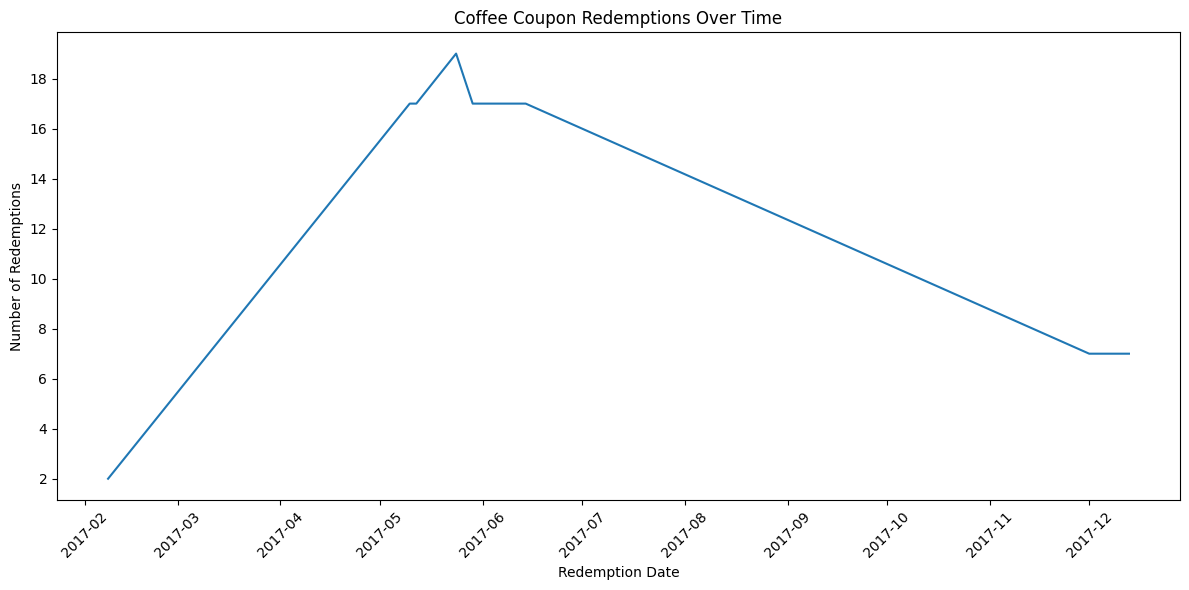

In [32]:


#plot the visualization of coffee coupon redemptions over time to see if there are any trends or seasonality in the data
plt.figure(figsize=(12,6))
sns.lineplot(x='redemption_date', y='count', data=daily)
plt.title('Coffee Coupon Redemptions Over Time')
plt.xlabel('Redemption Date')
plt.ylabel('Number of Redemptions')
plt.xticks(rotation=45)

#make y axis integer
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))


plt.tight_layout()
plt.show()


###### *We see here that there is a spike in coupon redemptions across May to July. Now let's look at the amount of coffee coupons offered versus redeemed and what season the offer began to better understand consumer behavior.*

In [33]:

# create new column redeemed status to show whether coffee coupon was redeemed or not based on the existence of value in redemption_date column
coffee_coupons["redeemed_status"] = coffee_coupons["redemption_date"].apply(
    lambda x: "Redeemed" if pd.notna(x) else "Not Redeemed"
)

# show count of which records are classified as redeemed versus not redeemed
coffee_coupons["redeemed_status"].value_counts()

,count
redeemed_status,
Redeemed,137
Not Redeemed,39


###### This output shows that all coffee coupons offered were not redeemed. We can now look at the redemption rate based on which season the coupon offer began.

$$
\text{Redemption Rate} =
\frac{\text{Number of Coupons Redeemed}}
{\text{Total Number of Coupons Offered}}
$$

In [34]:
#define function to calculate season based on month
def calculate_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

#create start date season column and apply previous function to show which season the campaign started in
coffee_coupons["start_date_season"] = coffee_coupons["start_date"].apply(calculate_season)


#create variable redemp_by_start_season to to hold counts of redeemed status by start date season
redemp_by_start_season = (
    coffee_coupons
        .groupby(["redeemed_status", "start_date_season"])
        .size()
        .reset_index(name="count")
        .pivot(index="start_date_season",
               columns="redeemed_status",
               values="count") #pivot table so that we can use redeemed and not redeemed as columns not rows
        .fillna(0) #fill null values with 0
)

redemp_by_start_season

redeemed_status,Not Redeemed,Redeemed
start_date_season,,
Fall,39.0,14.0
Spring,0.0,121.0
Winter,0.0,2.0


In [35]:
#calculate redemption rate by taking redeemed amount divided by total amount across redeemed and not redeemed
redemption_rate = (redemp_by_start_season.get("Redeemed", 0) /
    redemp_by_start_season.sum(axis=1))

#print redemption rate series with proper formatting for decimals and percentages
print((redemption_rate * 100).apply(lambda x: f"{x:.2f}%"))

start_date_season
Fall       26.42%
Spring    100.00%
Winter    100.00%
dtype: object


###### *Campaigns launched in Fall exhibit a lower redemption rate compared to Spring and Winter. However, the distribution of campaign launches across seasons is uneven, with Spring representing a significantly larger share of total offers and Winter having a very small sample size. This imbalance limits the reliability of direct cross-season performance comparisons.*

# ***2. Transaction Frequency Based on Time of Day as well as Weekday versus Weekend***

### Does Morning, Afternoon, or Night prove to be more popular for buying coffee products?

In [36]:
#join coffee products with transactions table
coffee_transactions = pd.merge(transactions,coffee_for_brewing,how="inner",on="product_id")
coffee_transactions.head()

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp,manufacturer_id,department,brand,product_category,product_type,package_size
0,1519,356,31198795316,10149601,1,1.49,0.00,0.0,0.0,1,2017-01-01 15:32:09,2024,GROCERY,National,COFFEE,GROUND FLVR DECAF COFFEE,1.75 OZ
1,1936,361,31198640454,1008596,1,1.99,0.00,0.0,0.0,1,2017-01-01 15:49:32,103,GROCERY,National,COFFEE,INSTANT COFFEE FLAVORED NO SWE,6.5 OZ
2,2488,324,31198990359,866488,1,6.99,2.00,0.0,0.0,1,2017-01-01 16:26:35,456,GROCERY,National,COFFEE,GROUND COFFEE,29.2 OZ
3,1483,370,31198901477,942475,1,1.67,1.62,0.0,0.0,1,2017-01-01 19:42:46,69,GROCERY,Private,COFFEE,GROUND COFFEE,13 OZ
4,1541,304,31198966679,922898,1,3.59,0.00,0.0,0.0,1,2017-01-01 20:22:47,456,GROCERY,National,COFFEE,GROUND FLVR REG COFFEE,10.8 OZ


In [37]:
# @title
#check that transaction_timestamp column is already datetime data type
print((coffee_transactions['transaction_timestamp'].dtype))

datetime64[ns]


In [38]:
# @title
#see how far the transactions span for coffee dataset and energy drink dataset
print((f"The earliest date for coffee transactions is {coffee_transactions['transaction_timestamp'].min()}"))
print((f"The latest date for energy drink transactions is {coffee_transactions['transaction_timestamp'].max()}\n"))


The earliest date for coffee transactions is 2017-01-01 15:32:09
The latest date for energy drink transactions is 2018-01-01 00:26:48



In [39]:
# create new column to show whether transaction occurred in morning, afternoon, of night
# first start be defining function that will take in column value and classify as Morning, Afternoon, or Night
def get_time_of_day(timestamp):
    hour = timestamp.hour
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Night'



In [40]:
# @title
# create a new column to show whether transaction occurred in morning, afternoon, of night for coffee drinks
coffee_transactions['time_of_day'] = coffee_transactions['transaction_timestamp'].apply(get_time_of_day)
coffee_transactions.head()

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp,manufacturer_id,department,brand,product_category,product_type,package_size,time_of_day
0,1519,356,31198795316,10149601,1,1.49,0.00,0.0,0.0,1,2017-01-01 15:32:09,2024,GROCERY,National,COFFEE,GROUND FLVR DECAF COFFEE,1.75 OZ,Afternoon
1,1936,361,31198640454,1008596,1,1.99,0.00,0.0,0.0,1,2017-01-01 15:49:32,103,GROCERY,National,COFFEE,INSTANT COFFEE FLAVORED NO SWE,6.5 OZ,Afternoon
2,2488,324,31198990359,866488,1,6.99,2.00,0.0,0.0,1,2017-01-01 16:26:35,456,GROCERY,National,COFFEE,GROUND COFFEE,29.2 OZ,Afternoon
3,1483,370,31198901477,942475,1,1.67,1.62,0.0,0.0,1,2017-01-01 19:42:46,69,GROCERY,Private,COFFEE,GROUND COFFEE,13 OZ,Night
4,1541,304,31198966679,922898,1,3.59,0.00,0.0,0.0,1,2017-01-01 20:22:47,456,GROCERY,National,COFFEE,GROUND FLVR REG COFFEE,10.8 OZ,Night


In [52]:
# group by time of day to see when most coffee transactions occur
# use nunique() to count unique baskets IDs and avoid double counting transactions that may have multiple coffee products in them
coffee_transactions_by_time = coffee_transactions.groupby('time_of_day')['basket_id'].nunique().sort_values(ascending=False)
coffee_transactions_by_time

,basket_id
time_of_day,
Night,3431
Afternoon,1542
Morning,112


In [42]:
# @title
# create a function to map day of week to weekday/weekend
def get_weekday_status(timestamp):
    day_of_week = timestamp.dayofweek  # 0-4 is Mon-Fri, 5-6 is Sat-Sun
    if day_of_week < 5:
        return 'Weekday'
    else:
        return 'Weekend'

# apply to coffee transactions dataset to create a new column show Weekday or Weekend status of transaction
coffee_transactions['weekday_status'] = coffee_transactions['transaction_timestamp'].apply(get_weekday_status)

coffee_transactions.head()

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp,manufacturer_id,department,brand,product_category,product_type,package_size,time_of_day,weekday_status
0,1519,356,31198795316,10149601,1,1.49,0.00,0.0,0.0,1,2017-01-01 15:32:09,2024,GROCERY,National,COFFEE,GROUND FLVR DECAF COFFEE,1.75 OZ,Afternoon,Weekend
1,1936,361,31198640454,1008596,1,1.99,0.00,0.0,0.0,1,2017-01-01 15:49:32,103,GROCERY,National,COFFEE,INSTANT COFFEE FLAVORED NO SWE,6.5 OZ,Afternoon,Weekend
2,2488,324,31198990359,866488,1,6.99,2.00,0.0,0.0,1,2017-01-01 16:26:35,456,GROCERY,National,COFFEE,GROUND COFFEE,29.2 OZ,Afternoon,Weekend
3,1483,370,31198901477,942475,1,1.67,1.62,0.0,0.0,1,2017-01-01 19:42:46,69,GROCERY,Private,COFFEE,GROUND COFFEE,13 OZ,Night,Weekend
4,1541,304,31198966679,922898,1,3.59,0.00,0.0,0.0,1,2017-01-01 20:22:47,456,GROCERY,National,COFFEE,GROUND FLVR REG COFFEE,10.8 OZ,Night,Weekend


In [43]:
coffee_transactions_wd = coffee_transactions.groupby('weekday_status')['basket_id'].nunique().sort_values(ascending=False)
coffee_transactions_wd

,basket_id
weekday_status,
Weekday,3251
Weekend,1834


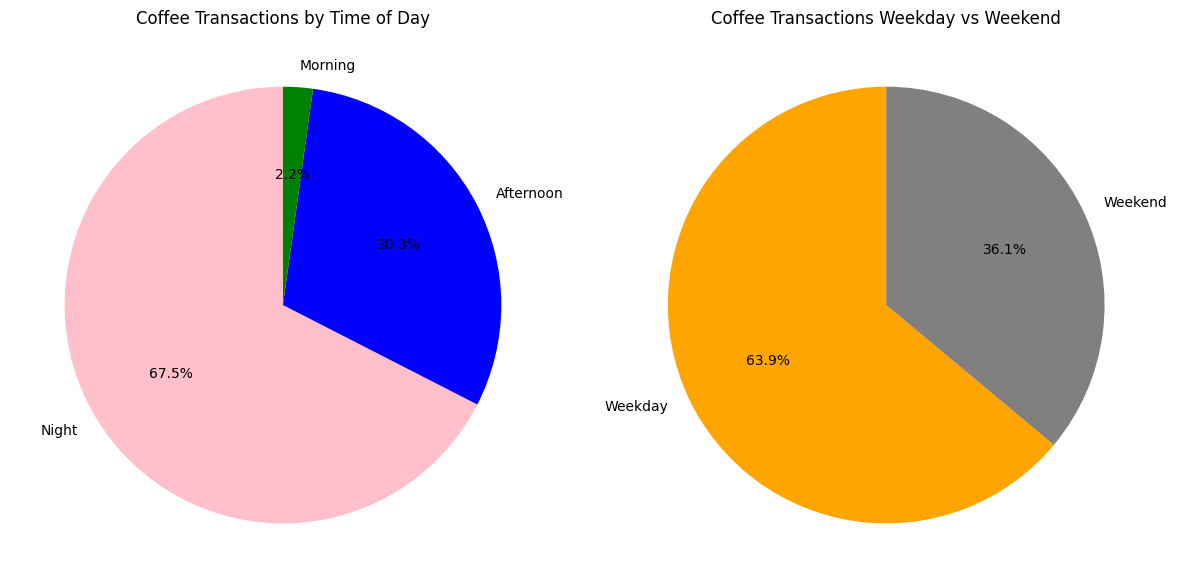

In [44]:
#plotting both
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# time of day pie chart plotting output for count depending on morning, afternoon, or night
axes[0].pie(
    coffee_transactions_by_time.values,
    labels=coffee_transactions_by_time.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['pink','blue','green']
)
axes[0].set_title('Coffee Transactions by Time of Day')

# pie chart plotting output for count depending on weekday versus weekend
axes[1].pie(
    coffee_transactions_wd.values,
    labels=coffee_transactions_wd.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['orange','grey']
)
axes[1].set_title('Coffee Transactions Weekday vs Weekend')

plt.tight_layout()
plt.show()

###### *From the two pie charts, we see that coffee is bought most commonly in the evenings and on weekdays.*

# ***3. Demographics of Coffee Drinkers***

- Let's now look at the demographics of those who drink coffee by taking coffee transactins and joining with demographic data to get a better idea of our target audience.

In [45]:
# join demographics to each coffee transaction
coffee_demo = coffee_transactions.merge(
    demographics,
    on="household_id",
    how="inner"
)
coffee_demo.head()

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,...,package_size,time_of_day,weekday_status,age,income,home_ownership,marital_status,household_size,household_comp,kids_count
0,2488,324,31198990359,866488,1,6.99,2.00,0.0,0.0,1,...,29.2 OZ,Afternoon,Weekend,45-54,35-49K,Homeowner,Unmarried,1,1 Adult No Kids,0
1,1483,370,31198901477,942475,1,1.67,1.62,0.0,0.0,1,...,13 OZ,Night,Weekend,19-24,Under 15K,None,Unmarried,1,1 Adult No Kids,0
2,1541,304,31198966679,922898,1,3.59,0.00,0.0,0.0,1,...,10.8 OZ,Night,Weekend,35-44,50-74K,None,Unmarried,1,1 Adult No Kids,0
3,1563,421,31198887054,901772,1,6.99,1.50,0.0,0.0,1,...,12 OZ,Night,Weekend,45-54,75-99K,Homeowner,Married,3,2 Adults Kids,1
4,2221,288,31198835984,1102845,1,4.47,1.12,0.0,0.0,1,...,39 OZ,Night,Weekend,65+,35-49K,Homeowner,Unmarried,1,1 Adult No Kids,0


In [46]:
#age analysis showing total sales by each age group
coffee_demo_age = coffee_demo.groupby("age")["sales_value"].sum().reset_index(name="Total Sales").sort_values("Total Sales", ascending=False)

coffee_demo_age.head()

,age,Total Sales
3,45-54,7835.54
2,35-44,4454.64
1,25-34,2394.17
4,55-64,1652.59
5,65+,1232.42


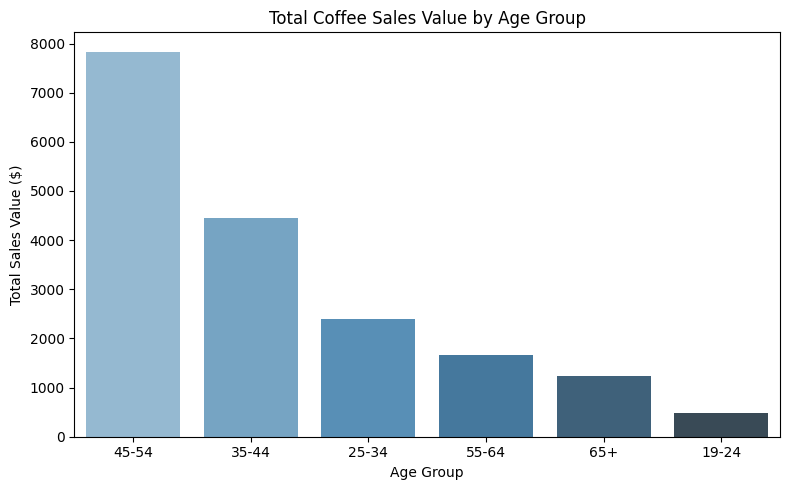

In [47]:
#age visualization plotting output of previous result
plt.figure(figsize=(8,5))
sns.barplot(
    x="age",
    y="Total Sales",
    data=coffee_demo_age,
    palette="Blues_d"
)
plt.title("Total Coffee Sales Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Value ($)")
plt.tight_layout()
plt.show()

In [48]:
#marital status analysis showing median sales value by each household size
coffee_demo_household_size = coffee_demo.groupby("household_size")["sales_value"].median().reset_index(name="Median Sales Value").sort_values("Median Sales Value", ascending=False)

coffee_demo_household_size.head()

,household_size,Median Sales Value
1,2,4.99
2,3,4.99
0,1,4.79
4,5+,4.17
3,4,4.09


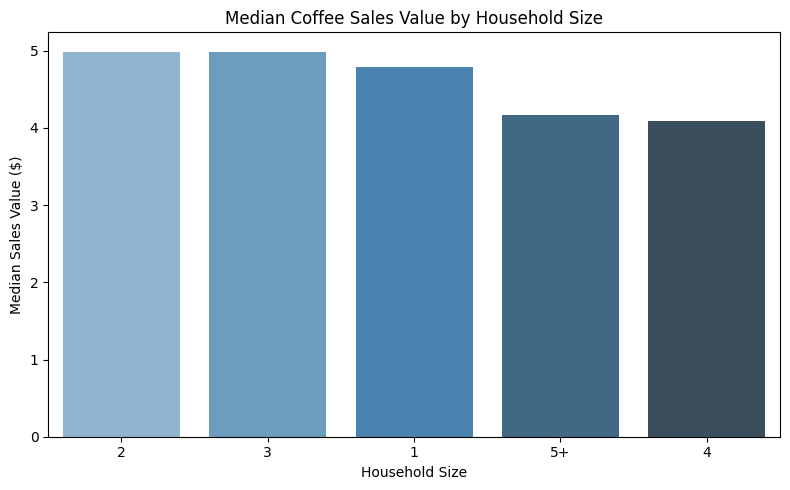

In [49]:
#household size visualization using output of previous result
plt.figure(figsize=(8,5))
sns.barplot(
    x="household_size",
    y="Median Sales Value",
    data=coffee_demo_household_size,
    palette="Blues_d"
)
plt.title("Median Coffee Sales Value by Household Size")
plt.xlabel("Household Size")
plt.ylabel("Median Sales Value ($)")
plt.tight_layout()
plt.show()

In [50]:
#income analysis showing average sales value by each income group
coffee_demo_income = coffee_demo.groupby("income")["sales_value"].mean().reset_index(name="Average Sales Value").sort_values("Average Sales Value", ascending=False).head()

coffee_demo_income.head()


,income,Average Sales Value
3,150-174K,7.637829
7,250K+,7.494196
1,125-149K,5.693333
5,200-249K,5.366000
0,100-124K,5.207571


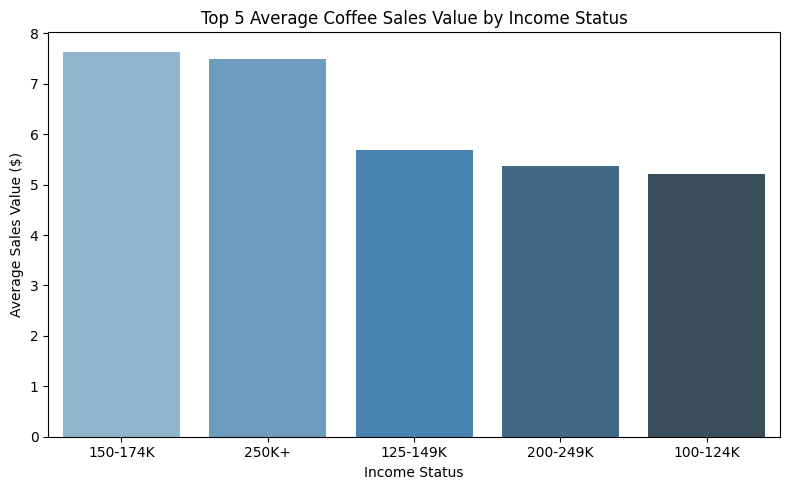

In [51]:
#income status visualization using output from previous result
plt.figure(figsize=(8,5))
sns.barplot(
    x="income",
    y="Average Sales Value",
    data=coffee_demo_income,
    palette="Blues_d"
)
plt.title("Top 5 Average Coffee Sales Value by Income Status")
plt.xlabel("Income Status")
plt.ylabel("Average Sales Value ($)")
plt.tight_layout()
plt.show()

###### *The three charts digging into demographics on age, household size, and income show some key statistics on the demographics of current coffee transactions:*
- 35-54 year olds drive the largest total sales value by a significant margin.
- The median sales value among household sizes 2 and 3 are around $5 with households of 1 following close behind.
- On average, those with annual incomes of 150-174k an 205k+ are spending the most on average.

#**Summary**

###**Observations**

#####


*   Coffee coupon redemptions increase during the late Spring and Summer months
*   Coffee purchases occur more frequently on weekdays during evening hours
*   Customers between the ages 35-54 represent the highest purchasing segment for coffee products
*   Households with annual incomes of $150,000 - $174,000 and $205,000+ spend the most on coffee



###**Recommendations**

##### Based on these observations we have the following recommendations:



*  Diversify Seasonal Campaign Timing
  
  Increase the number of coffee coupon campaigns that start during Fall and Winter to balance the seasonal coupon offers and drive more consistent redemptions throughout the year

*  Optimize Inventory During Peak Demand Periods

Ensure there is adequate stock levels during high demand periods like weekday evenings to prevent stockouts

*  Stimulate Morning and Afternoon Sales

Implement promotions to encourage coffee purchases during the morning and early afternoon hours to help smooth the demand distribution

*  Expand Targeting Beyond the Core Age Segment

Since the prime age of coffee purchasers are 35-54 there should be campaigns that target the age groups outside of this range to increase customer penetration




###**Conclusion**

##### Overall, this analysis identified key trends in coffee coupon redemptions, timing of transactions, and customer demographics. We found that there are seasonal spikes in late Spring and Summer, there are patterns that show a high frequency of coffee purchases in the weekday evenings, and a higher spending between ages 35-54 and higher-income households. These insights support more strategic campaign timing, inventory planning, and target marketing.

# **Limitations**
Limitations that we came across were how descriptive the fields were. We were unsure where to draw the line on iced coffee vs. hot and then coffee beans vs canned coffee. We also thought adding another feature to the campaign type/dataset would have helped a lot.